<a href="https://colab.research.google.com/github/ChenOnline/APEX_WVC/blob/main/EmpricalRuleHistogramVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I created a dummy student grades using google sheets;

**Published** as CSV file; get the address of this file;

Asked gemini to code "import data";

Copy/pasted my file in the code;

Asked gemini to create histogram;

Asked gemini to do empirical rule then I asked more to modify it;

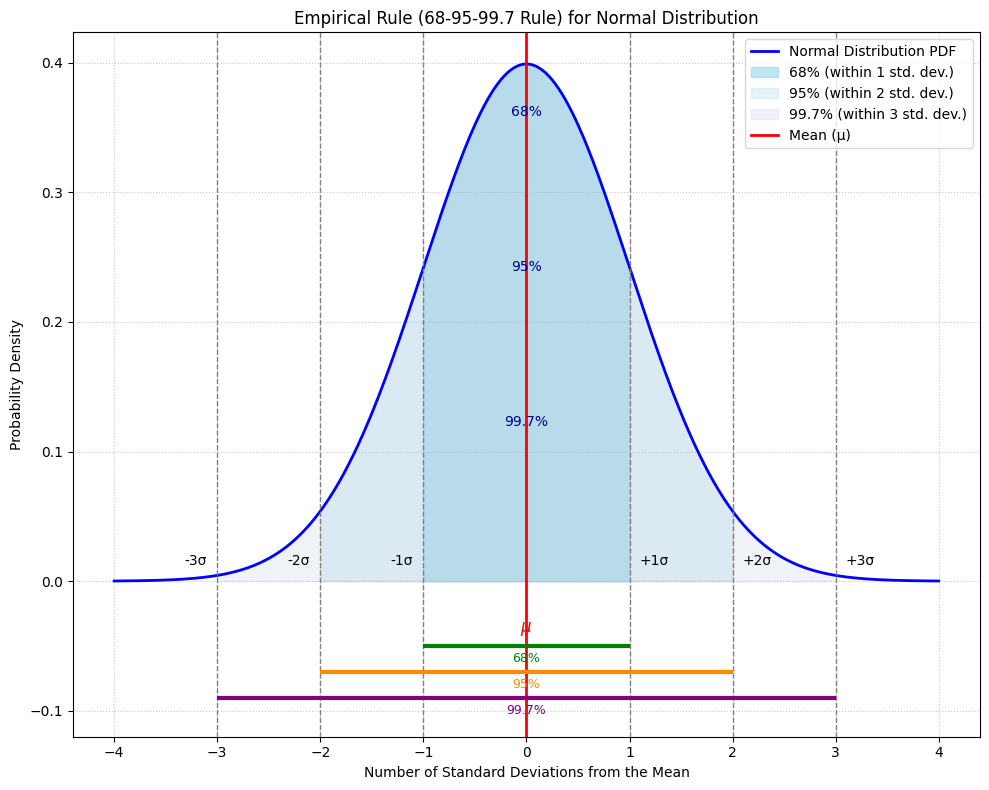

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define parameters for the normal distribution
mu = 0  # Mean
sigma = 1  # Standard deviation
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)

# Create the plot
plt.figure(figsize=(10, 8))

# Plot the probability density function (PDF) of the normal distribution
plt.plot(x, norm.pdf(x, mu, sigma), color='blue', lw=2, label='Normal Distribution PDF')

# Empirical Rule - 1 Standard Deviation (68%)
x_1_std = np.linspace(mu - sigma, mu + sigma, 100)
plt.fill_between(x_1_std, norm.pdf(x_1_std, mu, sigma), color='skyblue', alpha=0.5, label='68% (within 1 std. dev.)')

# Empirical Rule - 2 Standard Deviations (95%)
x_2_std = np.linspace(mu - 2 * sigma, mu + 2 * sigma, 100)
plt.fill_between(x_2_std, norm.pdf(x_2_std, mu, sigma), color='lightblue', alpha=0.3, label='95% (within 2 std. dev.)')

# Empirical Rule - 3 Standard Deviations (99.7%)
x_3_std = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 100)
plt.fill_between(x_3_std, norm.pdf(x_3_std, mu, sigma), color='lightsteelblue', alpha=0.2, label='99.7% (within 3 std. dev.)')

# Add vertical lines at standard deviations
for i in range(1, 4):
    plt.axvline(mu + i * sigma, color='gray', linestyle='--', lw=1)
    plt.axvline(mu - i * sigma, color='gray', linestyle='--', lw=1)
    plt.text(mu + i * sigma + 0.1, 0.01, f'+{i}\u03c3', verticalalignment='bottom', horizontalalignment='left')
    plt.text(mu - i * sigma - 0.1, 0.01, f'-{i}\u03c3', verticalalignment='bottom', horizontalalignment='right')

# Add text for percentages inside the curve
plt.text(mu, norm.pdf(mu, mu, sigma) * 0.9, '68%', horizontalalignment='center', color='darkblue', fontsize=10)
plt.text(mu, norm.pdf(mu, mu, sigma) * 0.6, '95%', horizontalalignment='center', color='darkblue', fontsize=10)
plt.text(mu, norm.pdf(mu, mu, sigma) * 0.3, '99.7%', horizontalalignment='center', color='darkblue', fontsize=10)

# Plot mean
plt.axvline(mu, color='red', linestyle='-', lw=2, label='Mean (\u03bc)')
plt.text(mu, -0.03, r'$\mu$', verticalalignment='top', horizontalalignment='center', color='red', fontsize=12)

# Add horizontal lines to indicate ranges below the x-axis
y_level_68 = -0.05 # Adjust this to place lines below the main plot area
y_level_95 = -0.07
y_level_99_7 = -0.09

# 68% range
plt.hlines(y_level_68, mu - sigma, mu + sigma, color='green', linestyle='-', lw=3)
plt.text(mu, y_level_68 - 0.005, '68%', horizontalalignment='center', verticalalignment='top', color='green', fontsize=9)

# 95% range
plt.hlines(y_level_95, mu - 2 * sigma, mu + 2 * sigma, color='darkorange', linestyle='-', lw=3)
plt.text(mu, y_level_95 - 0.005, '95%', horizontalalignment='center', verticalalignment='top', color='darkorange', fontsize=9)

# 99.7% range
plt.hlines(y_level_99_7, mu - 3 * sigma, mu + 3 * sigma, color='purple', linestyle='-', lw=3)
plt.text(mu, y_level_99_7 - 0.005, '99.7%', horizontalalignment='center', verticalalignment='top', color='purple', fontsize=9)

# Customize plot
plt.title('Empirical Rule (68-95-99.7 Rule) for Normal Distribution')
plt.xlabel('Number of Standard Deviations from the Mean')
plt.ylabel('Probability Density')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.ylim(bottom=-0.12) # Extend y-axis to show new lines
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# To import data, you typically use pandas.read_csv() for CSV files,
# or similar functions for other formats like pd.read_excel(), pd.read_sql(), etc.

# Replace 'your_data.csv' with the actual path to your CSV file.
# If the file is in your Google Drive, you'll need to mount your Drive first.
# Example: df = pd.read_csv('/content/drive/MyDrive/your_data.csv')

# For demonstration, let's create a dummy DataFrame if no file is provided.
try:
    # Attempt to read a CSV from a common location, or modify this path
    df = pd.read_csv('https://docs.google.com/spreadsheets/d/1D1bA5gbmtXPGctrsD1w54tqsMX_GJaIamWqN1DKIj0Q/export?format=csv&gid=0') # Corrected: Use direct export link for Google Sheet
    print("Data loaded successfully from 'your_data.csv'!")
except FileNotFoundError:
    print("File 'your_data.csv' not found. Creating a dummy DataFrame for demonstration.")
    data = {'Column1': [1, 2, 3, 4, 5],
            'Column2': ['A', 'B', 'C', 'D', 'E'],
            'Column3': [10.1, 20.2, 30.3, 40.4, 50.5]}
    df = pd.DataFrame(data)

# Display the first few rows of the DataFrame
display(df.head())

Data loaded successfully from 'your_data.csv'!


,Name,Grade
0,max1,63
1,max2,55
2,max3,39
3,max4,78
4,max5,66


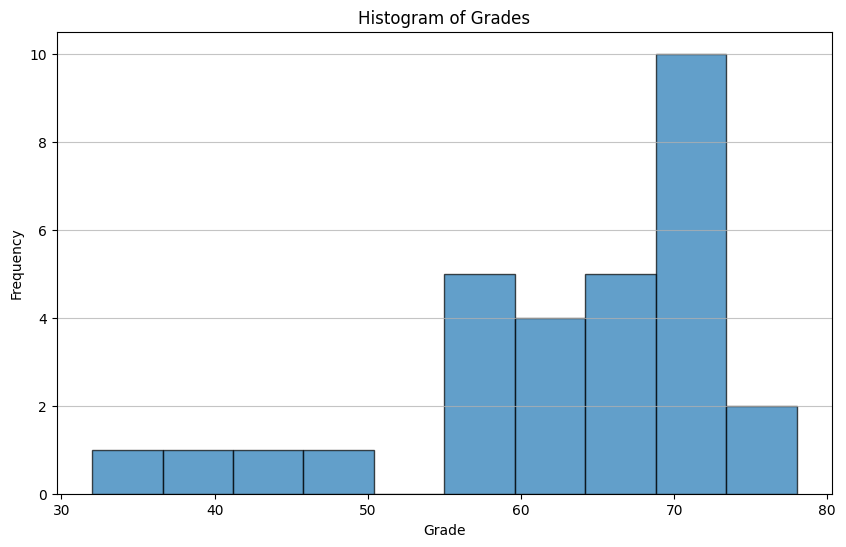

In [ ]:
import matplotlib.pyplot as plt

# Create a histogram for the 'Grade' column
plt.figure(figsize=(10, 6))
plt.hist(df['Grade'], bins=10, edgecolor='black', alpha=0.7)
plt.title('Histogram of Grades')
plt.xlabel('Grade')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()